In [ ]:
import kagglehub
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import shutil
import cv2
import numpy as np
from pathlib import Path
from collections import Counter
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.optim as optim


In [ ]:
pathCF = kagglehub.dataset_download("tuyenldvn/caucafall")

print("Path to dataset files:", pathCF)

100%|██████████| 7.76G/7.76G [01:50<00:00, 75.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tuyenldvn/caucafall/versions/2


In [ ]:
#-------------------------------------------------------------------------------
# Copying datasets into content/ from session's cache/
#-------------------------------------------------------------------------------

# Source directories
CFALL_SRC = "/root/.cache/kagglehub/datasets/tuyenldvn/caucafall/versions/2/Dataset CAUCAFall/CAUCAFall"
# Target directories
CFALL_DST = "/content/CAUCA_FALL"

def move_dataset(src, dst):
    if os.path.exists(dst):
        print(f"{dst} already exists. Skipping copy.")
    else:
        shutil.copytree(src, dst)
        print(f"Copied dataset to {dst}")

# Move datasets
move_dataset(CFALL_SRC, CFALL_DST)


Copied dataset to /content/CAUCA_FALL


Logits: [[ 0.14276543 -0.03485316]]
Raw Saliency: [0.00147054 0.00999988 0.01852922 0.02303123 0.02724556 0.03634173
 0.04618894 0.05894435 0.0724268  0.07977796 0.08489956 0.08759639
 0.08908085 0.12700119 0.18921212 0.21261381 0.20205743 0.17565573
 0.13114509 0.09077109 0.05660208 0.03148601 0.02447582 0.01992087
 0.02211784 0.02459676 0.02820349 0.03054547 0.0246665  0.01870626
 0.01160827 0.00451027]


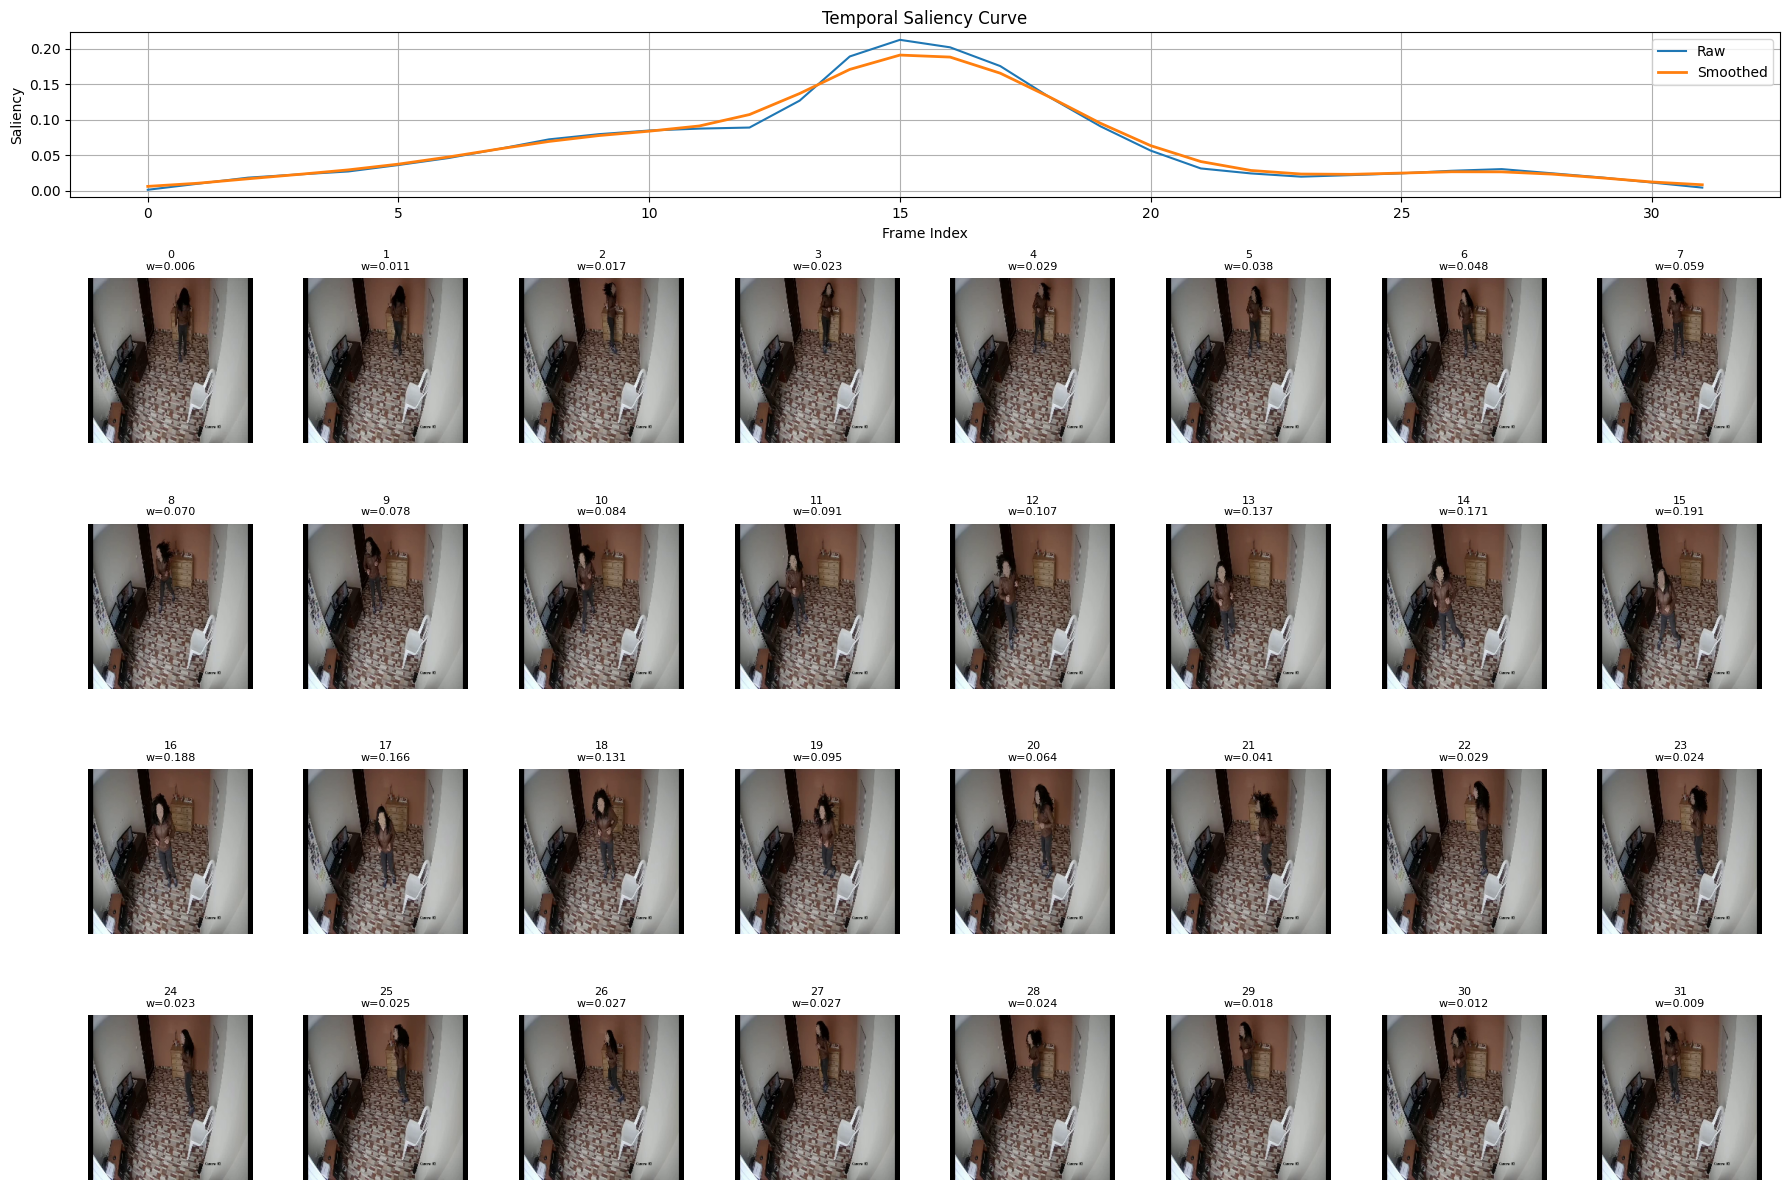

Saved as saliency_visualization.png
Status: Global Event Zone | Window: 12 to 19 | Varying K: 8


In [37]:
import json
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# =====================================================
# CONFIG
# =====================================================
VIDEO_PATH = r"/content/CAUCA_FALL/Subject.3/Hop/HopS3.avi"   # works for .avi or .mp4
CKPT_PATH  = r"/content/best_model_fold3.pth"

CLIP_LEN   = 32
FRAME_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# MODEL
# =====================================================
class Stage1_3DCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv3d(3,64,(3,7,7),(1,2,2),(1,3,3),padding_mode='replicate')
        self.bn1 = nn.BatchNorm3d(64)
        self.pool1 = nn.MaxPool3d((1,3,3),(1,2,2),(0,1,1))

        self.conv2 = nn.Conv3d(64,128,3, padding=1, padding_mode='replicate')
        self.bn2 = nn.BatchNorm3d(128)
        self.pool2 = nn.MaxPool3d(2,2)

        self.conv3 = nn.Conv3d(128,256,3,padding=1, padding_mode='replicate')
        self.bn3 = nn.BatchNorm3d(256)

        self.conv4 = nn.Conv3d(256,256,3,padding=1, padding_mode='replicate')
        self.bn4 = nn.BatchNorm3d(256)

        self.global_pool = nn.AdaptiveAvgPool3d((1,1,1))
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256,2)

    def forward(self,x, return_saliency=False):

        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))   # <-- saliency layer

       # --- SALIENCY (Improved with Edge Gating) ---
        sal = x.detach().pow(2).mean(dim=(1,3,4))  # (B, T')

        # Create a mask to dampen the very first and last temporal indices
        # T' is likely 16 here because of pool2
        T_prime = sal.shape[1]
        mask = torch.ones(T_prime).to(sal.device)
        mask[0] = 0.05  # Strongly suppress the first frame index
        mask[-1] = 0.5  # Slightly suppress the last
        sal = sal * mask

        # Now apply your scaling
        min_val = sal.min(dim=1, keepdim=True)[0]
        max_val = sal.max(dim=1, keepdim=True)[0]
        sal = (sal - min_val) / (max_val - min_val + 1e-6)

        # Softmax with temperature (5.0) helps highlight the fall peak
        sal = F.softmax(sal * 5.0, dim=1)

        #sal  = sal / (sal.sum(dim=1, keepdim=True) + 1e-6)

        x = F.relu(self.bn4(self.conv4(x)))
        x = self.global_pool(x).flatten(1)
        x = self.dropout(x)
        logits = self.fc(x)

        if return_saliency:
            return logits, sal
        return logits

# =====================================================
# LOAD MODEL
# =====================================================
model = Stage1_3DCNN().to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# =====================================================
# UNIFORM SAMPLING
# =====================================================
cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), "Cannot open video"

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
assert total_frames > 0, "Empty video"

indices = np.linspace(0, total_frames-1, CLIP_LEN).astype(int)

frames = []
for idx in indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
    ret, frame = cap.read()
    if not ret:
        raise RuntimeError("Frame read failed")

    frame = cv2.resize(frame, (FRAME_SIZE, FRAME_SIZE))
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames.append(frame)

cap.release()

frames_np = np.array(frames).astype(np.float32) / 255.0
clip = torch.from_numpy(frames_np).permute(3,0,1,2).unsqueeze(0).to(DEVICE)

# =====================================================
# RUN MODEL
# =====================================================
with torch.no_grad():
    logits, saliency = model(clip, return_saliency=True)

saliency = saliency.squeeze(0).cpu().numpy()

# Interpolate from 16 → 32 (since pool2 halves T)
saliency_interp = np.interp(
    np.linspace(0, len(saliency)-1, CLIP_LEN),
    np.arange(len(saliency)),
    saliency
)

# Smooth curve
saliency_smooth = gaussian_filter1d(saliency_interp, sigma=1.2)

print("Logits:", logits.cpu().numpy())
print("Raw Saliency:", saliency_interp)

# =====================================================
# PLOT CLEANLY
# =====================================================
fig = plt.figure(figsize=(18,12))

# ---- Saliency Curve (Top Full Width) ----
ax_curve = plt.subplot(5, 1, 1)
ax_curve.plot(saliency_interp, label="Raw")
ax_curve.plot(saliency_smooth, linewidth=2, label="Smoothed")
ax_curve.set_title("Temporal Saliency Curve")
ax_curve.set_xlabel("Frame Index")
ax_curve.set_ylabel("Saliency")
ax_curve.legend()
ax_curve.grid(True)

# ---- Frame Grid (4 rows x 8 cols) ----
rows = 4
cols = 8

for i in range(CLIP_LEN):
    ax = plt.subplot(5, cols, cols + i + 1)
    ax.imshow(frames[i])
    ax.set_title(f"{i}\nw={saliency_smooth[i]:.3f}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig("saliency_visualization.png", dpi=300)
plt.show()

print("Saved as saliency_visualization.png")

def get_global_active_window(saliency_values, energy_threshold=0.15):
    # 1. Standardize and find 'Active' frames
    # We use a lower multiplier (0.5) to be more inclusive of "pre-fall" motion
    threshold = np.mean(saliency_values) + (0.5 * np.std(saliency_values))
    is_active = saliency_values > threshold

    # 2. Label all contiguous islands
    from scipy.ndimage import label
    labels, num_features = label(is_active)

    if num_features == 0:
        return 0, len(saliency_values) - 1, "Static/Uniform"

    total_energy = np.sum(saliency_values)
    significant_indices = []

    # 3. Filter islands by Energy Contribution (Global Context)
    for i in range(1, num_features + 1):
        mask = (labels == i)
        region_energy = np.sum(saliency_values[mask])

        # If this peak is a significant part of the whole clip's motion
        if (region_energy / total_energy) > energy_threshold:
            significant_indices.extend(np.where(mask)[0])

    if not significant_indices:
        # Fallback to the single highest peak if nothing meets the energy threshold
        peak_idx = np.argmax(saliency_values)
        return max(0, peak_idx-2), min(len(saliency_values)-1, peak_idx+2), "Peak Only"

    # 4. The Global Varying K
    start = min(significant_indices)
    end = max(significant_indices)

    return start, end, "Global Event Zone"

# Example usage in your pipeline:
start, end, status = get_global_active_window(saliency_smooth)
varying_k = end - start + 1

print(f"Status: {status} | Window: {start} to {end} | Varying K: {varying_k}")




In [ ]:
# =====================================================
# SAVE STAGE 1 OUTPUT FOR STAGE 2
# =====================================================

# Prepare the data dictionary
# We include original video path, the localized window,
# the importance weights, and the actual frame numbers sampled.
stage1_data = {
    "video_path": VIDEO_PATH,
    "active_window": [int(start), int(end)],
    "varying_k": int(varying_k),
    "detection_status": status,
    "saliency_weights": saliency_smooth.tolist(),
    "clip_indices": indices.tolist()  # Maps 0-31 indices to actual video frame numbers
}

# Define the output path
json_output_path = "stage1_output.json"

# Write to JSON
with open(json_output_path, "w") as f:
    json.dump(stage1_data, f, indent=4)

print("\n" + "="*50)
print(f"STAGE 1 JSON GENERATED: {json_output_path}")
print(f"Status: {status}")
print(f"Target Window: Frames {start} to {end} (K={varying_k})")
print("="*50)